# Comparison Smoothing

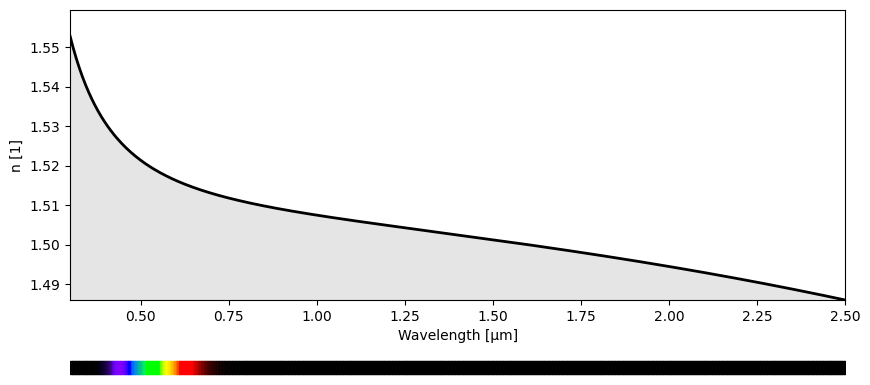

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)

aperture_radius = 12.7
NBK7 = dit.materials["NBK7"]
dit.plotting.wavelength.plot(NBK7)


In [2]:
n_enviroment = 1.000293
wave_len = 0.5328

lens_pos1D = 0.5
lens_thickness = 6.5
curvature = 0.05
detector_distance = 25.

grid_size = 32


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False

lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,NBK7,aperture_radius)
lens1.lens_thickness.requires_grad = False

detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

aperture_radius_det = aperture_radius*0.5
detector = dit.Detector(detector_transform,plane_surface,aperture_radius_det)
#gridxt = torch.linspace(-aperture_radius,aperture_radius,grid_size)
#grid_delta =gridxt[1]-gridxt[0] 


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector})

In [3]:
num_pix = 100
__gridxt = torch.linspace(-aperture_radius_det,aperture_radius_det,num_pix)
print("num_pix",num_pix,"grid_delta",__gridxt[1]-__gridxt[0])


num_pix 100 grid_delta tensor(0.1283)


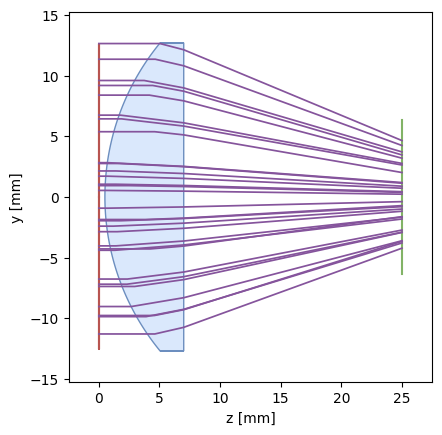

In [4]:

x,weights = light_source.sample(30)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)

#dit.plotting.system3D.plot(system,RayPaths,show_grid=False)
dit.plotting.system2D.plot(system,RayPaths)

In [54]:
__irrs = []
sigmas = [0.2,0.5,1.0]
for sigma in sigmas:
    smoother = dit.nonimaging.smoothing.GaussianSmootherSquare(aperture_radius_det,num_pix,sigma)
    irr = dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=100000,method_ray_tracing="monte_carlo")
    #dit.plotting.quantity2D.intensity(irr,f"irradiance ($\sigma$={smoother.sigma} mm)",[-aperture_radius,aperture_radius])
    __irrs.append(irr)

In [67]:
from image_helper import image_from_grid
rows_extent = [[-aperture_radius, aperture_radius, -aperture_radius, aperture_radius]] * len(sigmas)
irrs = [np.clip(irr,0.0,0.016) for irr in __irrs]

image_grid = [irrs]
rows_vidx = [0]
rows_cmap = ["jet"]
cbar_titles = ["[W/m²]"]
columns_title = [f"σ={sigma} mm" for sigma in sigmas]
rows_title = ["Smoothed Irradiance"]
kwargs = dict(image_grid=image_grid,
                rows_extent=rows_extent,
                rows_vidx=rows_vidx,
                rows_cmap=rows_cmap,
                rows_title=rows_title,
                cbar_titles=cbar_titles,
                columns_title=columns_title)
        
out = image_from_grid(**kwargs,
                                max_num_column=5,
                            font_size_PIL=35,
                            cbar_labelsize=20,
                            cbar_title_fontsize=20)
out = out[0]


_image_from_grid 1 3


[tensor(True), tensor(False), tensor(False)]


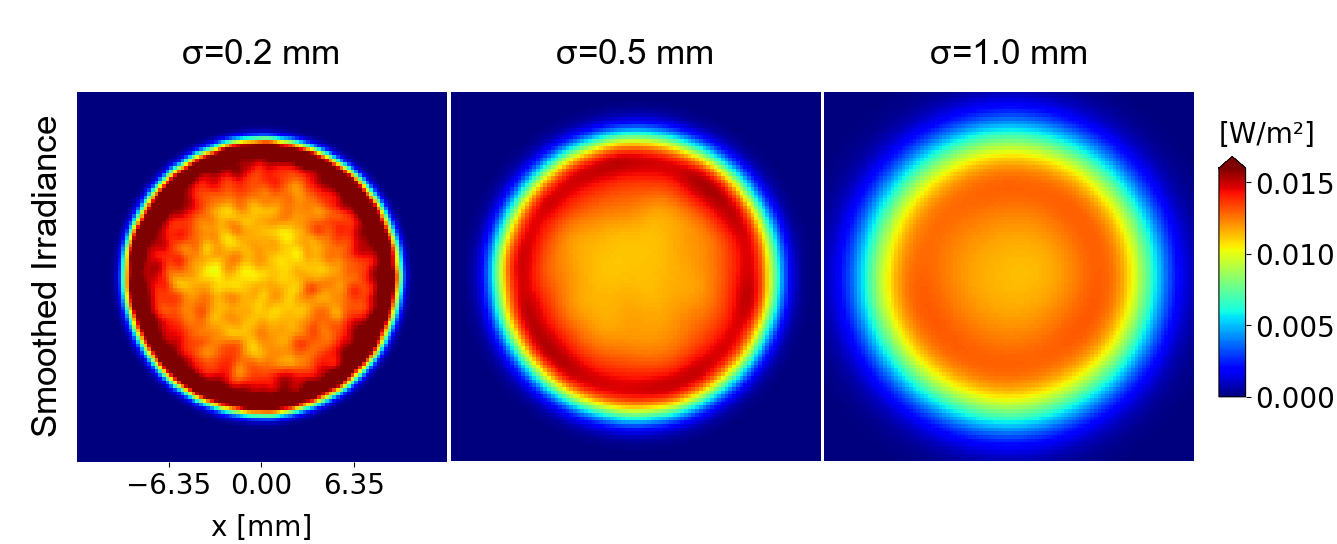

In [68]:
from PIL import Image, ImageDraw, ImageFont
original_image = Image.open(out)
print([(elem>=0.016).any() for elem in irrs])
original_image
    


<Figure size 640x480 with 0 Axes>

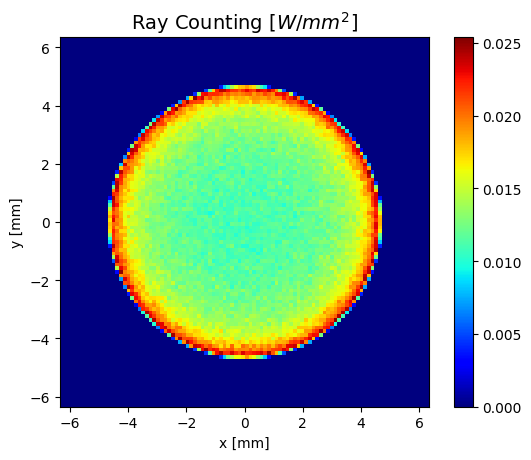

In [8]:
import numpy as np
import torch
from diffinytrace.render import binned_irradiance

grid = dit.target_grid.GridSquare(aperture_radius_det,num_pix)
raycounting = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=2000000,method_ray_tracing="monte_carlo")
dit.plotting.quantity2D.intensity(raycounting,f"Ray Counting",[-aperture_radius_det,aperture_radius_det])

In [9]:

smoother_baseline_irrs = {}
    
def run_all_simulations(num_simulations,num_sigmapoints):
    global smoother_baseline_irrs
    errors_per_num_rays = {}
    error_variance_per_num_rays = {}
    rc_difference_per_num_rays = {}

    #,5000,10000
    for num_rays in [1000,2000,3000]:
        print("start num_rays",num_rays)
        errors_per_sigma = {}
        rc_difference_per_sigma = {}
        #sigmas = [0.05,0.1,0.2]
        error_variance_per_sigma = {}

        quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo")
        get_smoother = lambda sigma: dit.nonimaging.smoothing.GaussianSmootherSquare(aperture_radius_det,num_pix,sigma)
        for sigma in np.linspace(0.2,5.,num_sigmapoints):
            smoother = get_smoother(sigma)
            error_stack = []
            rc_diff_stack = []
            if not (100000,smoother) in smoother_baseline_irrs.keys():
                smoother_baseline_irrs[(100000,aperture_radius_det,num_pix,sigma)] = quick_render(100000,smoother)
            smoother_baseline_irr = smoother_baseline_irrs[(100000,aperture_radius_det,num_pix,sigma)]
            #print("after baseline render")
            for k in range(num_simulations):
                irr = quick_render(num_rays,smoother)
                
                rc_difference = torch.sqrt(smoother.get_integral_over_distribution((irr-raycounting)**2.0))
                #torch.linalg.norm(irr.reshape(-1) - raycounting.reshape(-1))
                rc_diff_stack.append(rc_difference)
                L2error = torch.sqrt(smoother.get_integral_over_distribution((irr-smoother_baseline_irr)**2.0))
                #torch.linalg.norm(irr.reshape(-1) - smoother_baseline_irr.reshape(-1))
                
                error_stack.append(L2error)

            rc_difference_per_sigma[sigma] = rc_diff_stack
            errors_per_sigma[sigma] = error_stack
            error_variance_per_sigma[sigma] = torch.var(torch.tensor(error_stack).reshape(-1))
            
        errors_per_num_rays[num_rays] = errors_per_sigma
        error_variance_per_num_rays[num_rays] = error_variance_per_sigma
        rc_difference_per_num_rays[num_rays] = rc_difference_per_sigma

        print("end num_rays",num_rays)
    return errors_per_num_rays, error_variance_per_num_rays, rc_difference_per_num_rays

In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np


errors_per_num_rays1, error_variance_per_num_rays1, rc_difference_per_num_rays1 = run_all_simulations(num_simulations=16,num_sigmapoints=256)
# Get the number of different ray counts


start num_rays 1000
end num_rays 1000
start num_rays 2000
end num_rays 2000
start num_rays 3000
end num_rays 3000


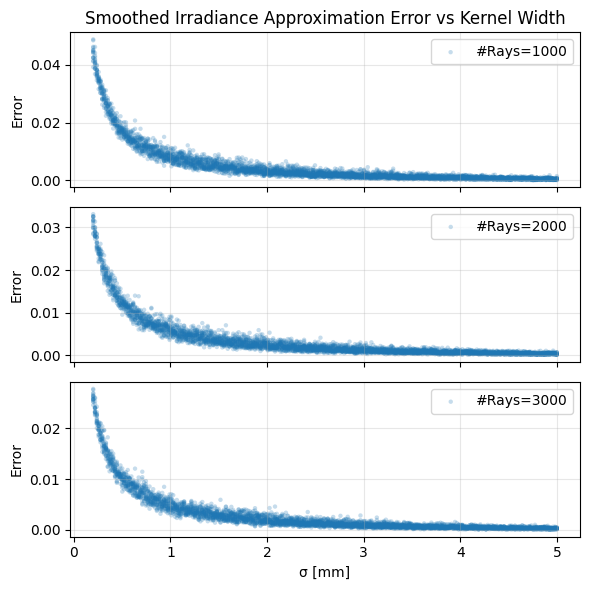

In [17]:
num_ray_counts = len(errors_per_num_rays1)

# Create subplots with vertical arrangement
fig, axes = plt.subplots(num_ray_counts, 1, figsize=(6, 2 * num_ray_counts), sharex=True)

# If there's only one subplot, make sure axes is a list
if num_ray_counts == 1:
    axes = [axes]

# Plot each ray count in its own subplot
for idx, (num_rays, errors_per_sigma) in enumerate(errors_per_num_rays1.items()):
    plot_sigmas = [] 
    plot_errors = []
    
    for key, errors in errors_per_sigma.items():
        x_val = torch.tensor(key).repeat(len(errors))
        plot_sigmas.extend(x_val)
        plot_errors.extend(errors)

    axes[idx].scatter(plot_sigmas, plot_errors,s=10, alpha=0.25, 
                     edgecolors='none', label=f"#Rays={num_rays}")
    
    axes[idx].set_ylabel('Error')
    axes[idx].grid(True, alpha=0.3)
    #axes[idx].set_title(f'L2 Error vs Kernel Width (#Rays={num_rays})')
    axes[idx].legend()
# Set x-label only on the bottom subplot
axes[-1].set_xlabel('σ [mm]')
axes[0].set_title(f'Smoothed Irradiance Approximation Error vs Kernel Width')
#fig.set_title("L2 Error vs Kernel Width")
plt.tight_layout()
plt.show()

In [12]:
errors_per_num_rays2, error_variance_per_num_rays2, rc_difference_per_num_rays2 = run_all_simulations(num_simulations=256,num_sigmapoints=16)


start num_rays 1000
end num_rays 1000
start num_rays 2000
end num_rays 2000
start num_rays 3000
end num_rays 3000


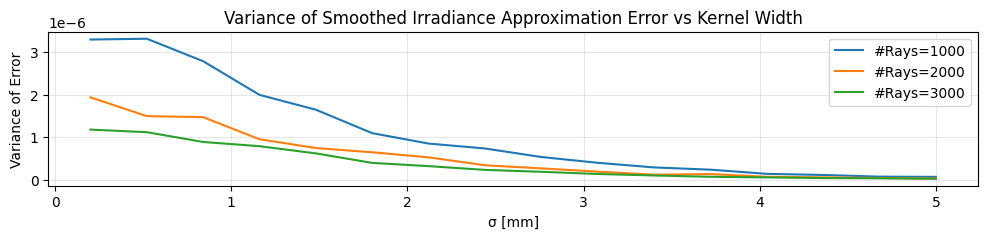

In [21]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))
    
for num_rays, variance_per_sigma in error_variance_per_num_rays2.items():
    plot_sigmas = [] 
    plot_variance = []
    for key, var in variance_per_sigma.items():
        #print("key",key,"errors",)
        plot_sigmas.append(key)
        plot_variance.append(var)

    plt.plot(plot_sigmas,plot_variance, '-',label=f"#Rays={num_rays}")


plt.xlabel('σ [mm]')
plt.ylabel('Variance of Error')
#plt.xscale('log')
#plt.yscale('log')
plt.grid(True, alpha=0.3)
    
plt.legend()

plt.title('Variance of Smoothed Irradiance Approximation Error vs Kernel Width')
plt.show()



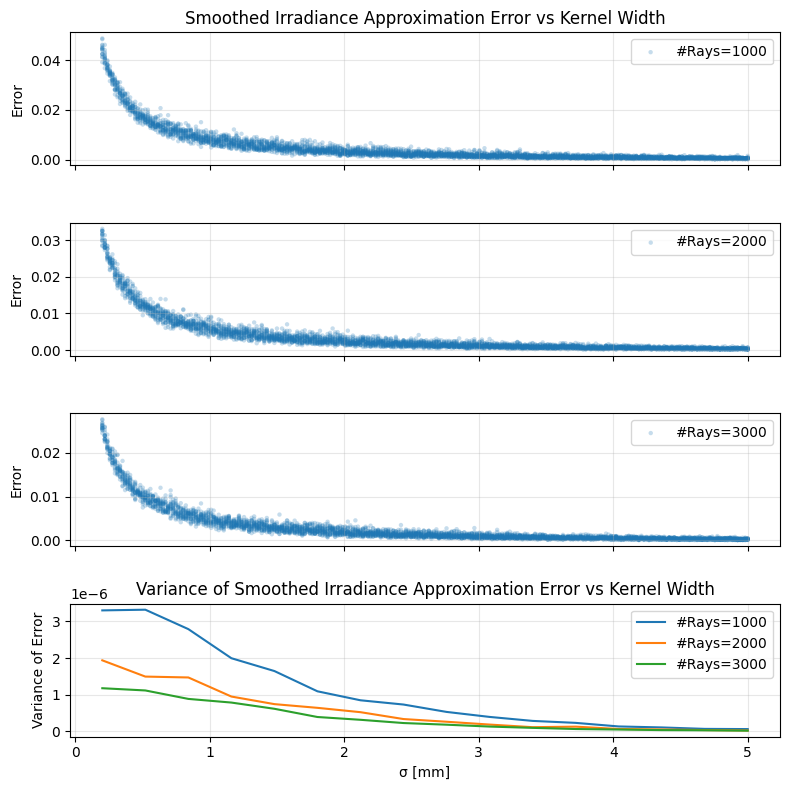

In [27]:
num_ray_counts = len(errors_per_num_rays1)

# Create subplots with vertical arrangement
fig, axes = plt.subplots(num_ray_counts+1, 1, figsize=(8, 2 * (num_ray_counts+1)), sharex=True)

# If there's only one subplot, make sure axes is a list
if num_ray_counts == 1:
    axes = [axes]

# Plot each ray count in its own subplot
for idx, (num_rays, errors_per_sigma) in enumerate(errors_per_num_rays1.items()):
    plot_sigmas = [] 
    plot_errors = []
    
    for key, errors in errors_per_sigma.items():
        x_val = torch.tensor(key).repeat(len(errors))
        plot_sigmas.extend(x_val)
        plot_errors.extend(errors)

    axes[idx].scatter(plot_sigmas, plot_errors,s=10, alpha=0.25, 
                     edgecolors='none', label=f"#Rays={num_rays}")
    
    axes[idx].set_ylabel('Error')
    axes[idx].grid(True, alpha=0.3)
    #axes[idx].set_title(f'L2 Error vs Kernel Width (#Rays={num_rays})')
    axes[idx].legend()
# Set x-label only on the bottom subplot
#axes[-1].set_xlabel('σ [mm]')
axes[0].set_title(f'Smoothed Irradiance Approximation Error vs Kernel Width')
#fig.set_title("L2 Error vs Kernel Width")


for num_rays, variance_per_sigma in error_variance_per_num_rays2.items():
    plot_sigmas = [] 
    plot_variance = []
    for key, var in variance_per_sigma.items():
        #print("key",key,"errors",)
        plot_sigmas.append(key)
        plot_variance.append(var)

    axes[-1].plot(plot_sigmas,plot_variance, '-',label=f"#Rays={num_rays}")


#plt.xlabel('σ [mm]')
axes[-1].set_ylabel('Variance of Error')
#plt.xscale('log')
#plt.yscale('log')
axes[-1].grid(True, alpha=0.3)
    
axes[-1].legend()

axes[-1].set_xlabel('σ [mm]')
axes[-1].set_title('Variance of Smoothed Irradiance Approximation Error vs Kernel Width')

plt.tight_layout()
plt.show()

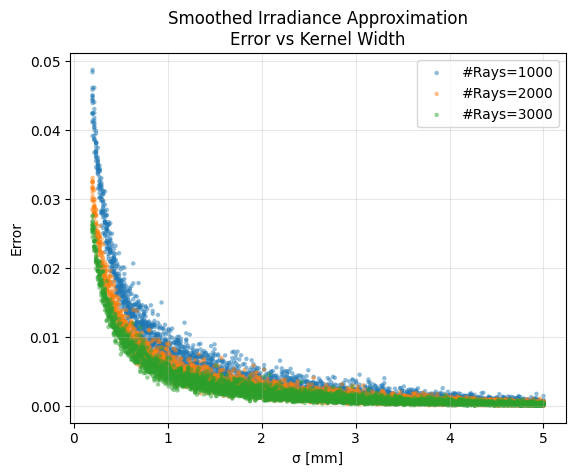

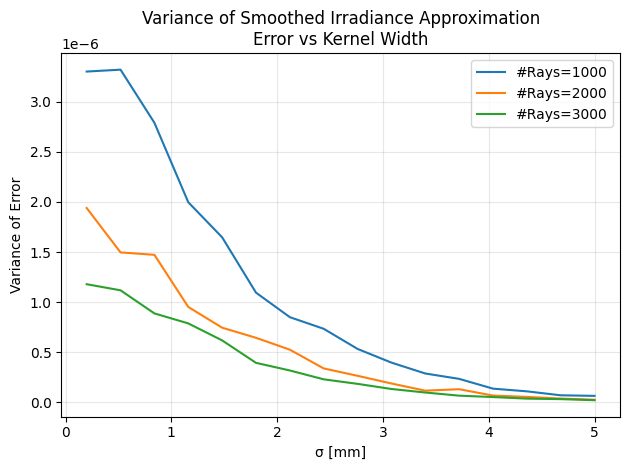

In [41]:
num_ray_counts = len(errors_per_num_rays1)

# Create subplots with vertical arrangement

# If there's only one subplot, make sure axes is a list

axes = plt.gca()

# Plot each ray count in its own subplot
for idx, (num_rays, errors_per_sigma) in enumerate(errors_per_num_rays1.items()):
    plot_sigmas = [] 
    plot_errors = []
    
    for key, errors in errors_per_sigma.items():
        x_val = torch.tensor(key).repeat(len(errors))
        plot_sigmas.extend(x_val)
        plot_errors.extend(errors)

    axes.scatter(plot_sigmas, plot_errors,s=10, alpha=0.5, 
                     edgecolors='none', label=f"#Rays={num_rays}")
    
axes.set_ylabel('Error')
axes.grid(True, alpha=0.3)    

axes.set_xlabel('σ [mm]')
axes.legend()
# Set x-label only on the bottom subplot
#axes[-1].set_xlabel('σ [mm]')
axes.set_title('Smoothed Irradiance Approximation\nError vs Kernel Width')
#fig.set_title("L2 Error vs Kernel Width")
plt.show()
plt.cla()

axes = plt.gca()

for num_rays, variance_per_sigma in error_variance_per_num_rays2.items():
    plot_sigmas = [] 
    plot_variance = []
    for key, var in variance_per_sigma.items():
        #print("key",key,"errors",)
        plot_sigmas.append(key)
        plot_variance.append(var)

    axes.plot(plot_sigmas,plot_variance, '-',label=f"#Rays={num_rays}")


#plt.xlabel('σ [mm]')
axes.set_ylabel('Variance of Error')
#plt.xscale('log')
#plt.yscale('log')
axes.grid(True, alpha=0.3)
    
axes.legend()

axes.set_xlabel('σ [mm]')
axes.set_title('Variance of Smoothed Irradiance Approximation\nError vs Kernel Width')

plt.tight_layout()
plt.show()